<a href="https://colab.research.google.com/github/muajnstu/CAST/blob/main/E3_Perception_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

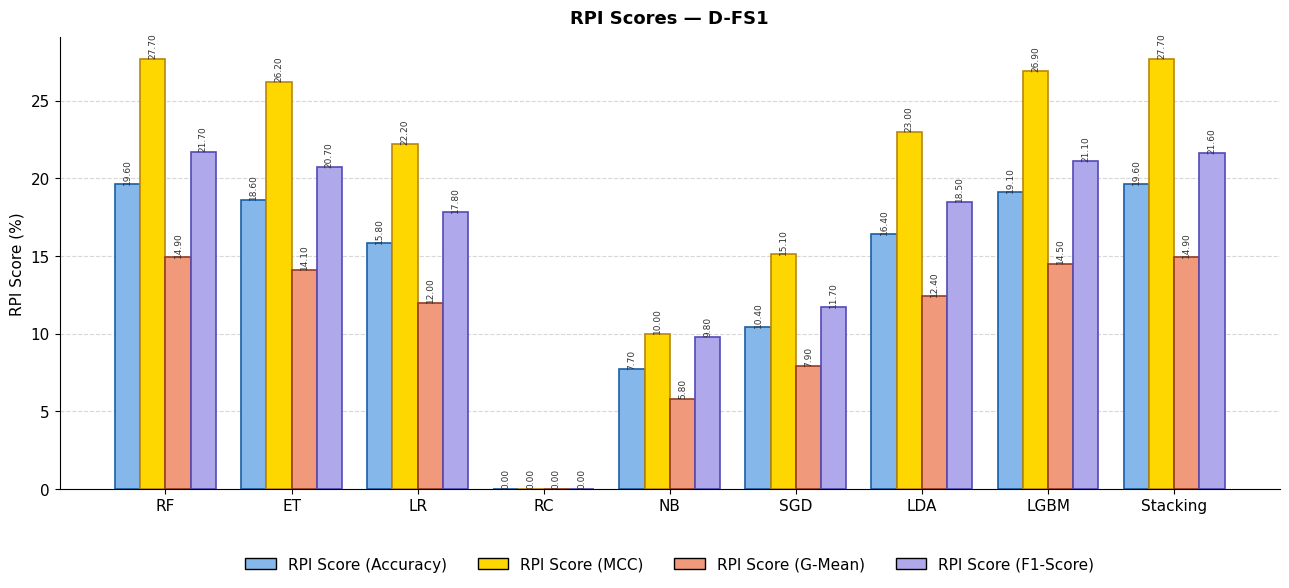

Saved: rpi_D_FS1.png


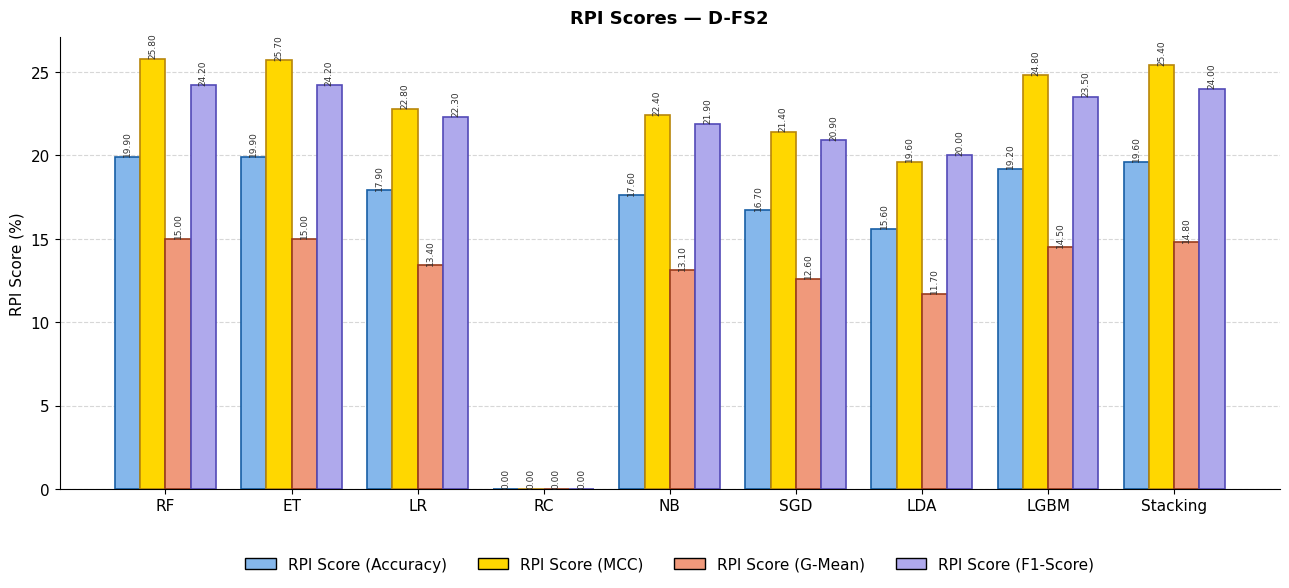

Saved: rpi_D_FS2.png


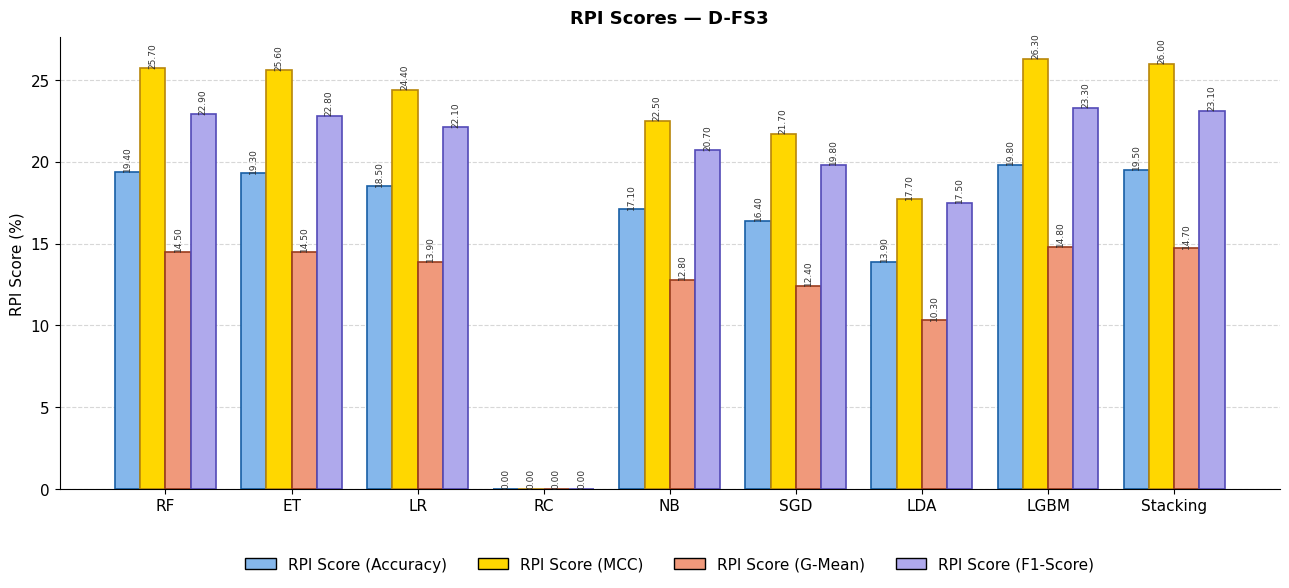

Saved: rpi_D_FS3.png


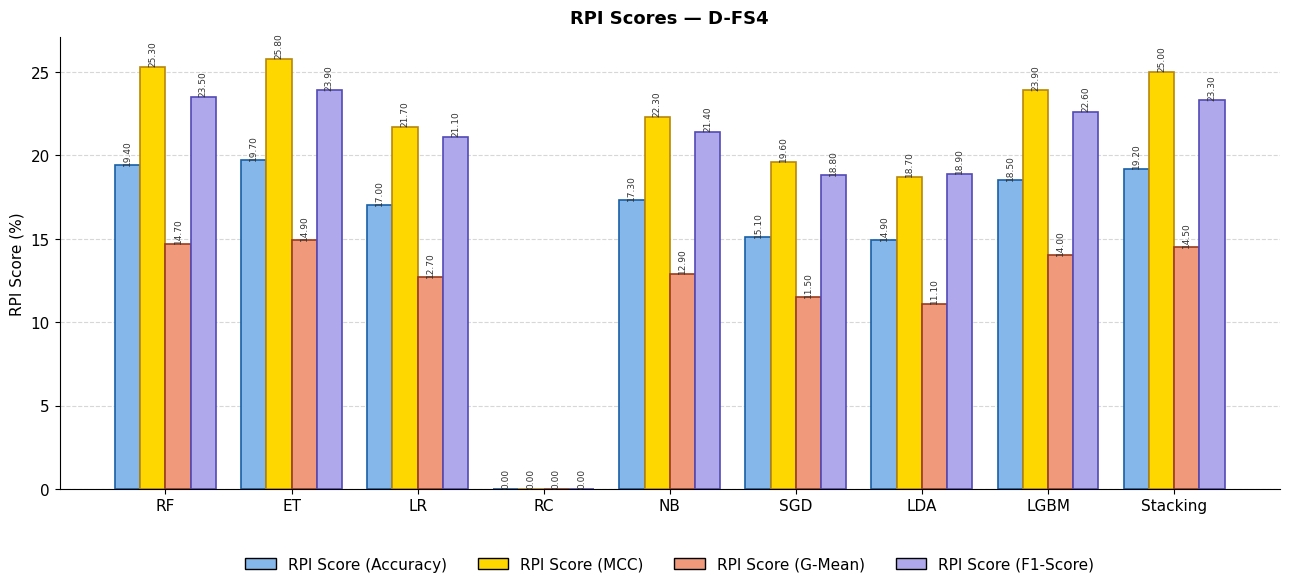

Saved: rpi_D_FS4.png


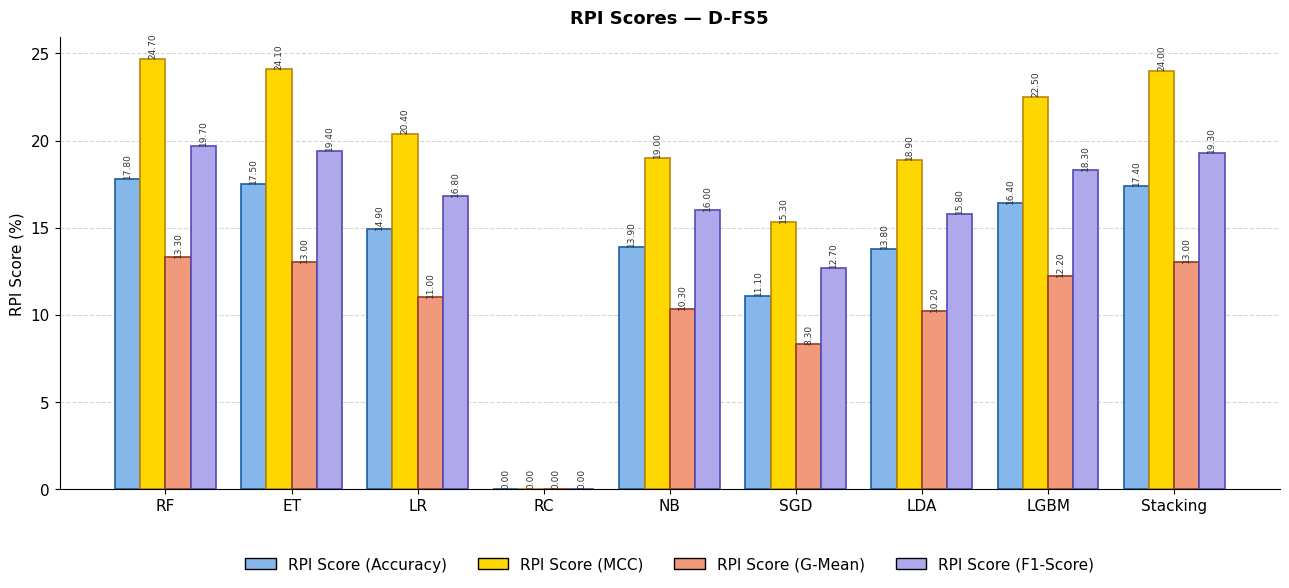

Saved: rpi_D_FS5.png


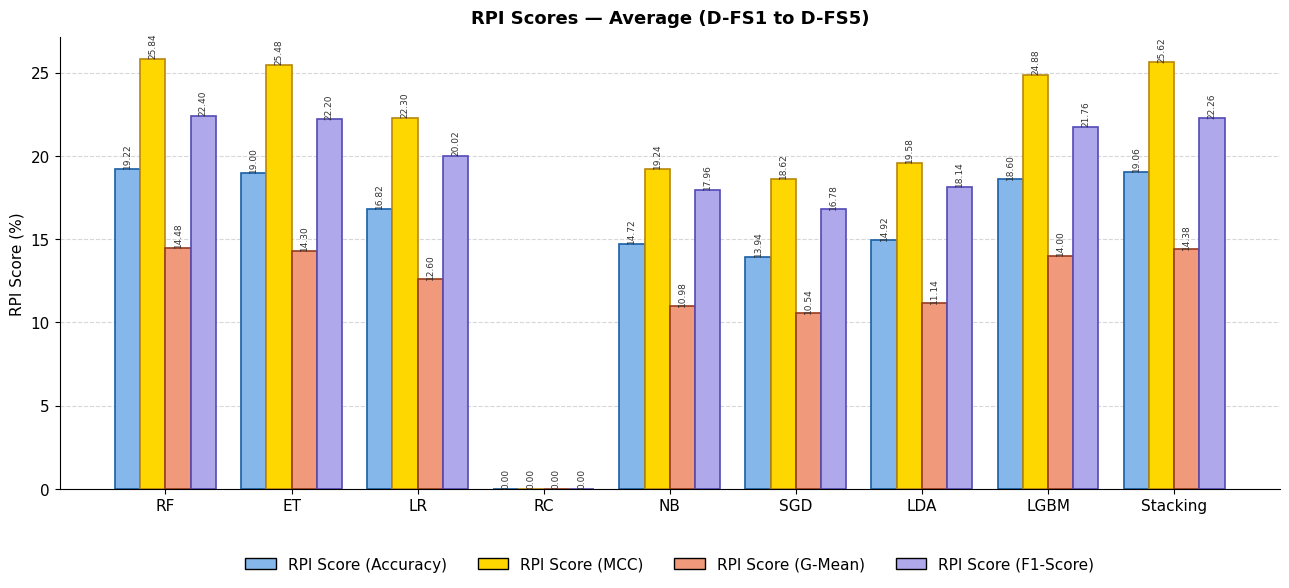

Saved: rpi_average_all.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

raw = {
    "D-FS1": {
        "RF":       [0.938, 0.909, 0.953, 0.938],
        "ET":       [0.928, 0.894, 0.945, 0.928],
        "LR":       [0.900, 0.854, 0.924, 0.899],
        "RC":       [0.742, 0.632, 0.804, 0.721],
        "NB":       [0.819, 0.732, 0.862, 0.819],
        "SGD":      [0.846, 0.783, 0.883, 0.838],
        "LDA":      [0.906, 0.862, 0.928, 0.906],
        "LGBM":     [0.933, 0.901, 0.949, 0.932],
        "Stacking": [0.938, 0.909, 0.953, 0.937],
    },
    "D-FS2": {
        "RF":       [0.951, 0.928, 0.963, 0.950],
        "ET":       [0.951, 0.927, 0.963, 0.950],
        "LR":       [0.931, 0.898, 0.947, 0.931],
        "RC":       [0.752, 0.670, 0.813, 0.708],
        "NB":       [0.928, 0.894, 0.944, 0.927],
        "SGD":      [0.919, 0.884, 0.939, 0.917],
        "LDA":      [0.908, 0.866, 0.930, 0.908],
        "LGBM":     [0.944, 0.918, 0.958, 0.943],
        "Stacking": [0.948, 0.924, 0.961, 0.948],
    },
    "D-FS3": {
        "RF":       [0.955, 0.933, 0.965, 0.954],
        "ET":       [0.954, 0.932, 0.965, 0.953],
        "LR":       [0.946, 0.920, 0.959, 0.946],
        "RC":       [0.761, 0.676, 0.820, 0.725],
        "NB":       [0.932, 0.901, 0.948, 0.932],
        "SGD":      [0.925, 0.893, 0.944, 0.923],
        "LDA":      [0.900, 0.853, 0.923, 0.900],
        "LGBM":     [0.959, 0.939, 0.968, 0.958],
        "Stacking": [0.956, 0.936, 0.967, 0.956],
    },
    "D-FS4": {
        "RF":       [0.949, 0.925, 0.962, 0.949],
        "ET":       [0.952, 0.930, 0.964, 0.953],
        "LR":       [0.925, 0.889, 0.942, 0.925],
        "RC":       [0.755, 0.672, 0.815, 0.714],
        "NB":       [0.928, 0.895, 0.944, 0.928],
        "SGD":      [0.906, 0.868, 0.930, 0.902],
        "LDA":      [0.904, 0.859, 0.926, 0.903],
        "LGBM":     [0.940, 0.911, 0.955, 0.940],
        "Stacking": [0.947, 0.922, 0.960, 0.947],
    },
    "D-FS5": {
        "RF":       [0.950, 0.927, 0.962, 0.949],
        "ET":       [0.947, 0.921, 0.959, 0.946],
        "LR":       [0.921, 0.884, 0.939, 0.920],
        "RC":       [0.772, 0.680, 0.829, 0.752],
        "NB":       [0.911, 0.870, 0.932, 0.912],
        "SGD":      [0.883, 0.833, 0.912, 0.879],
        "LDA":      [0.910, 0.869, 0.931, 0.910],
        "LGBM":     [0.936, 0.905, 0.951, 0.935],
        "Stacking": [0.946, 0.920, 0.959, 0.945],
    },
}

datasets   = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models     = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics    = ["Accuracy", "MCC", "G-Mean", "F1-Score"]   # AUROC বাদ

style = {
    "Accuracy": dict(color="#85B7EB", edgecolor="#185FA5", linewidth=1.2),
    "MCC":      dict(color="#FFD700", edgecolor="#B8860B", linewidth=1.2),
    "G-Mean":   dict(color="#F0997B", edgecolor="#993C1D", linewidth=1.2),
    "F1-Score": dict(color="#AFA9EC", edgecolor="#534AB7", linewidth=1.2),
}

bar_width = 0.20
x         = np.arange(len(models))
n_metrics = len(metrics)
offsets   = np.linspace(-(n_metrics - 1) / 2,
                         (n_metrics - 1) / 2,
                         n_metrics) * bar_width


def compute_rpi(ds_data):
    """
    RPI(model, metric) = (score - min_score) * 100
    min_score নেওয়া হয় ওই metric এ সব valid model এর মধ্যে।
    RC যদি minimum হয়, তার RPI = 0 — কিন্তু bar দেখানোর জন্য
    আলাদাভাবে 0-value bar + "0.00" label রাখা হয়।
    """
    rpi = {m: [] for m in models}
    for ki in range(len(metrics)):
        valid_vals = [ds_data[m][ki] for m in models if ds_data[m][ki] is not None]
        min_v = min(valid_vals) if valid_vals else 0
        for m in models:
            v = ds_data[m][ki]
            rpi[m].append((v - min_v) * 100 if v is not None else None)
    return rpi


def draw_chart(ax, rpi, title):
    for j, metric in enumerate(metrics):
        vals = []
        for m in models:
            v = rpi[m][j]
            vals.append(v if v is not None else 0.0)

        bars = ax.bar(x + offsets[j], vals, width=bar_width,
                      label=metric, **style[metric])

        # প্রতিটা bar এর উপর value label
        for i, (bar, m) in enumerate(zip(bars, models)):
            v = rpi[m][j]
            if v is None:
                continue
            ypos = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                ypos + 0.02,
                f"{v:.2f}",
                ha="center", va="bottom",
                fontsize=6.5, color="#333333",
                rotation=90
            )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("RPI Score (%)", fontsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


legend_handles = [
    mpatches.Patch(
        label=f"RPI Score ({m})",
        facecolor=style[m]["color"],
        edgecolor="black"
    )
    for m in metrics
]
# ────────────────────────────────────────────
for ds in datasets:
    rpi = compute_rpi(raw[ds])

    fig, ax = plt.subplots(figsize=(13, 6))
    draw_chart(ax, rpi, f"RPI Scores — {ds}")

    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.12), ncol=4,
              fontsize=11, frameon=False)

    plt.tight_layout()
    fname = f"rpi_{ds.replace('-', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# ── ২.  average combined graph ─────────────────────────
avg_rpi = {m: [0.0] * len(metrics) for m in models}

for ds in datasets:
    rpi = compute_rpi(raw[ds])
    for m in models:
        for ki in range(len(metrics)):
            avg_rpi[m][ki] += (rpi[m][ki] if rpi[m][ki] is not None else 0.0) / len(datasets)

fig, ax = plt.subplots(figsize=(13, 6))
draw_chart(ax, {m: avg_rpi[m] for m in models}, "RPI Scores — Average (D-FS1 to D-FS5)")

ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=4,
          fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("rpi_average_all.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: rpi_average_all.png")

Critical Diagram Of Classifiers


Significantly different pairs:
  RF vs LDA
  RF vs SGD
  RF vs RC
  ET vs RC
  Stacking vs RC
  LGBM vs RC


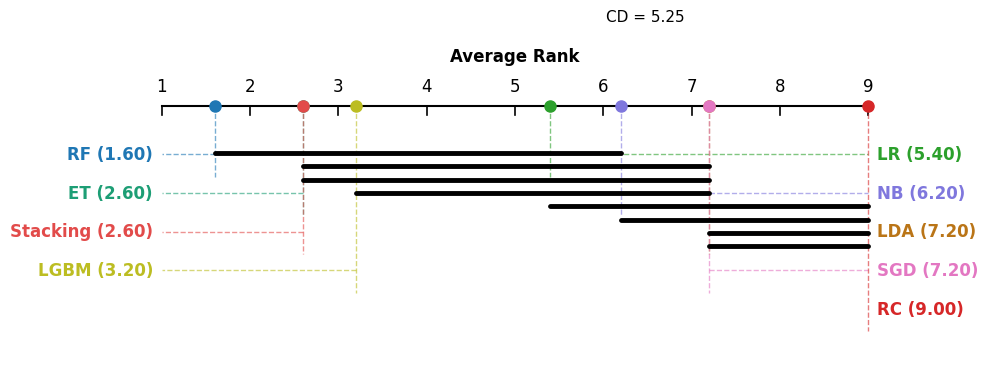

Done. Saved as cd_diagram.png


In [10]:
n_methods = len(models)
# Removed n_metrics = 4 as it's not used and inconsistent with len(metrics)

scores = np.zeros((len(datasets), len(models)))

for i, ds in enumerate(datasets):
    for j, model in enumerate(models):
        model_performance_tuples = raw[ds][model]
        valid_means = [t for t in model_performance_tuples if t is not None]
        if valid_means:
            scores[i, j] = np.mean(valid_means)
        else:
            scores[i, j] = np.nan # Assign NaN if all metrics are None for this model/dataset

ranks = np.zeros_like(scores)
for i in range(len(datasets)):
    # higher score = better → negate for ascending rank
    ranks[i] = rankdata(-scores[i])

mean_ranks = ranks.mean(axis=0)
N = len(datasets)
k = len(models)


#Friedman_Test
stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

#Nemenyi_Test
q_alpha = 3.03   # Nemenyi, alpha=0.05, k=9 (updated from 2.850 for k=6)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

sorted_idx   = np.argsort(mean_ranks)
sorted_names = [models[i] for i in sorted_idx]
sorted_ranks = mean_ranks[sorted_idx]

sig_pairs = []
for (i, j) in combinations(range(k), 2):
    if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
        sig_pairs.append((sorted_names[i], sorted_names[j]))

print("\nSignificantly different pairs:")
for p in sig_pairs:
    print(f"  {p[0]} vs {p[1]}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0.5, k + 0.5)
ax.set_ylim(-2.5, 2.0)
ax.axis("off")

axis_y = 1.2
ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
for r in range(1, k + 1):
    ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
    ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
            fontsize=12, color="black")
ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
        ha="center", va="bottom", fontsize=12, fontweight="bold")

cd_x_start = k - CD + 0.1
cd_y       = axis_y + 0.95
ax.annotate("", xy=(k + 0.1, cd_y),
            xytext=(cd_x_start, cd_y),
            arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08],
        color="black", lw=1.5)
ax.plot([k + 0.1, k + 0.1], [cd_y - 0.08, cd_y + 0.08],
        color="black", lw=1.5)
ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15,
        f"CD = {CD:.2f}", ha="center", va="bottom", fontsize=11)

# Updated colors_map to include all models and remove unused ones
initial_colors_map = {
    "ET":       "#1D9E75",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Stacking": "#E24B4A",
}

num_models_to_color = len(models)
# Use a colormap to get distinct colors
# 'tab10' provides 10 distinct colors, which is enough for 9 models
cmap = plt.colormaps['tab10'].resampled(num_models_to_color)

colors_map = {}
for idx, model_name in enumerate(models):
    if model_name in initial_colors_map:
        colors_map[model_name] = initial_colors_map[model_name]
    else:
        colors_map[model_name] = mcolors.to_hex(cmap(idx))

# split labels: top half left side, bottom half right side
n_left  = k // 2
n_right = k - n_left

label_y_top    =  0.55
label_y_step   =  0.52
line_drop      = -0.30

for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
    color = colors_map[name]
    # dot on axis
    ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

    if pos < n_left:
        # left side — labels go above-left
        ly = label_y_top - pos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(0.9, ly, f"{name} ({rank:.2f})",
                ha="right", va="center", fontsize=12,
                color=color, fontweight="bold")
    else:
        # right side — labels go above-right
        rpos = pos - n_left
        ly   = label_y_top - rpos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                ha="left", va="center", fontsize=12,
                color=color, fontweight="bold")

clique_y   = axis_y - 0.45
clique_step = 0.18
drawn = []

for i in range(k):
    group = [i]
    for j in range(i + 1, k):
        pair = (sorted_names[i], sorted_names[j])
        pair_r = (sorted_names[j], sorted_names[i])
        if pair not in sig_pairs and pair_r not in sig_pairs:
            group.append(j)
    if len(group) > 1:
        key = tuple(group)
        if key not in drawn:
            drawn.append(key)
            bar_y = clique_y - len(drawn) * clique_step
            x_start = sorted_ranks[group[0]]
            x_end   = sorted_ranks[group[-1]]
            ax.plot([x_start, x_end], [bar_y, bar_y],
                    color="black", lw=3.5, solid_capstyle="round")

sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"

plt.tight_layout()
plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Done. Saved as cd_diagram.png")


  D-FS1  |  Friedman p = 0.0000  |  CD = 5.25
Significantly different pairs:
  RF vs LDA


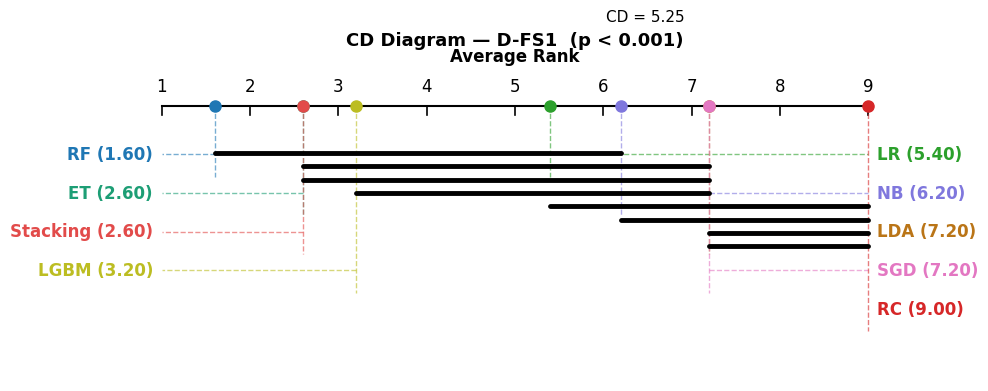

Saved: cd_D_FS1.png
  RF vs SGD


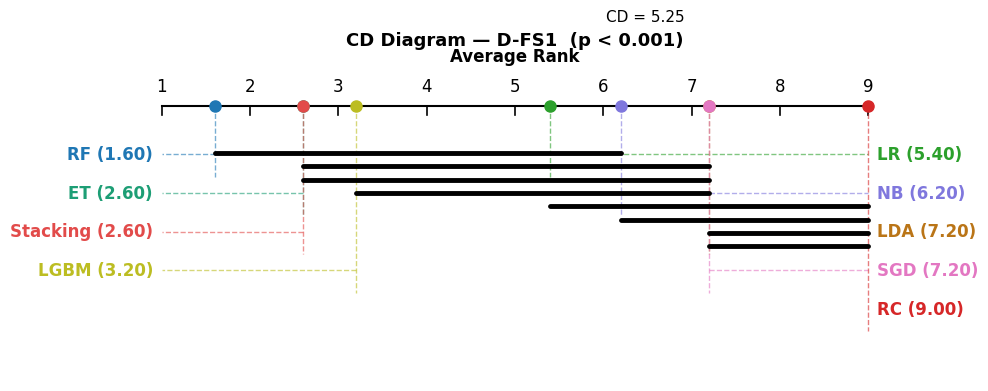

Saved: cd_D_FS1.png
  RF vs RC


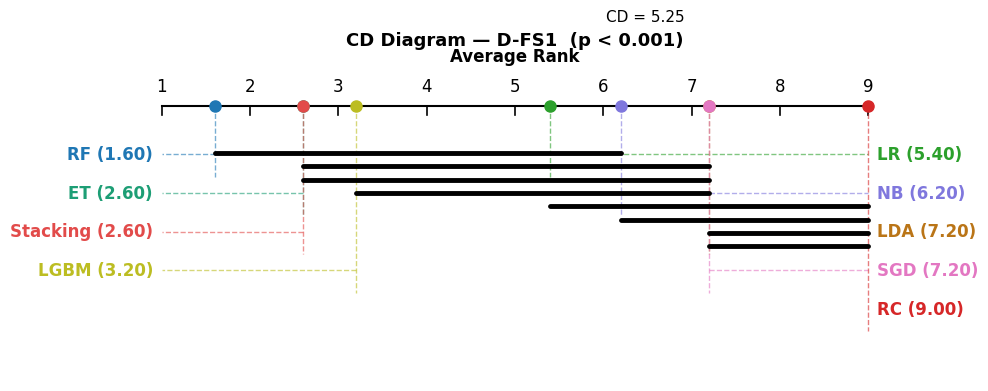

Saved: cd_D_FS1.png
  ET vs RC


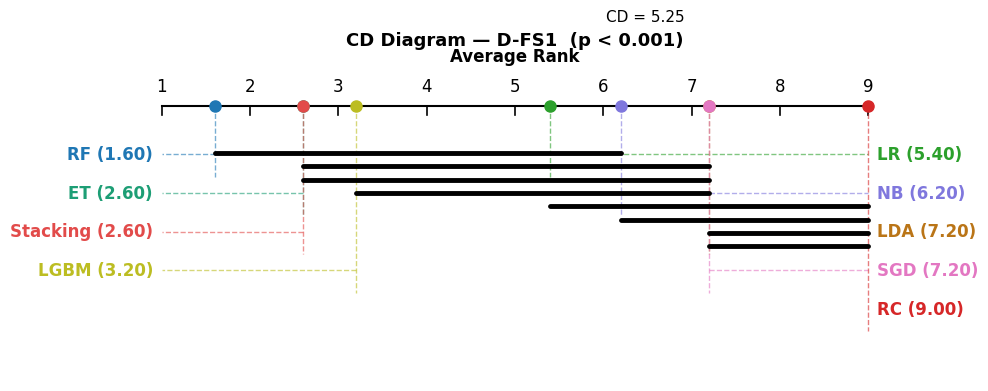

Saved: cd_D_FS1.png
  Stacking vs RC


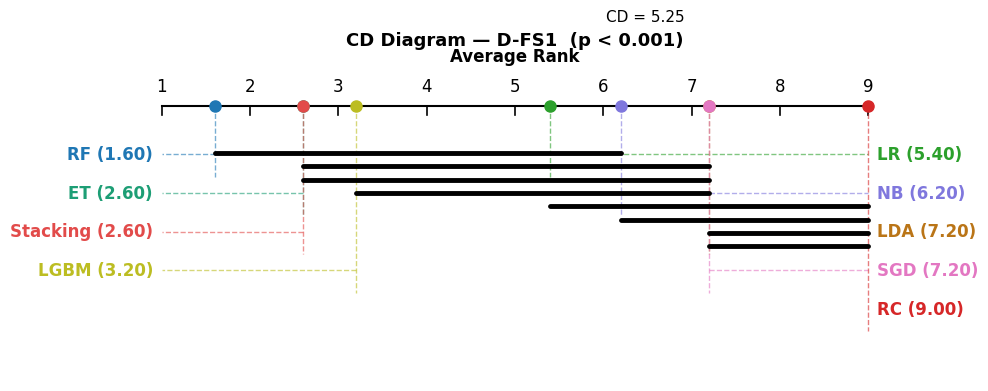

Saved: cd_D_FS1.png
  LGBM vs RC


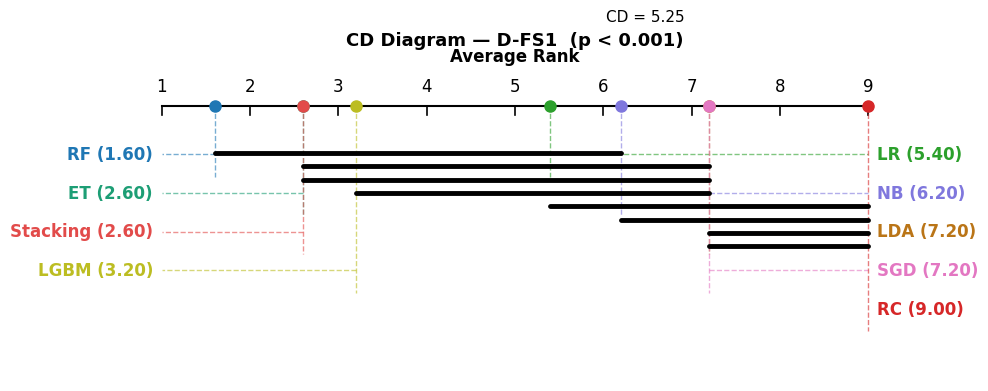

Saved: cd_D_FS1.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

raw = {
    "D-FS1": {
        "RF":       [0.938, 0.909, 0.953, 0.938],
        "ET":       [0.928, 0.894, 0.945, 0.928],
        "LR":       [0.900, 0.854, 0.924, 0.899],
        "RC":       [0.742, 0.632, 0.804, 0.721],
        "NB":       [0.819, 0.732, 0.862, 0.819],
        "SGD":      [0.846, 0.783, 0.883, 0.838],
        "LDA":      [0.906, 0.862, 0.928, 0.906],
        "LGBM":     [0.933, 0.901, 0.949, 0.932],
        "Stacking": [0.938, 0.909, 0.953, 0.937],
    },
    "D-FS2": {
        "RF":       [0.951, 0.928, 0.963, 0.950],
        "ET":       [0.951, 0.927, 0.963, 0.950],
        "LR":       [0.931, 0.898, 0.947, 0.931],
        "RC":       [0.752, 0.670, 0.813, 0.708],
        "NB":       [0.928, 0.894, 0.944, 0.927],
        "SGD":      [0.919, 0.884, 0.939, 0.917],
        "LDA":      [0.908, 0.866, 0.930, 0.908],
        "LGBM":     [0.944, 0.918, 0.958, 0.943],
        "Stacking": [0.948, 0.924, 0.961, 0.948],
    },
    "D-FS3": {
        "RF":       [0.955, 0.933, 0.965, 0.954],
        "ET":       [0.954, 0.932, 0.965, 0.953],
        "LR":       [0.946, 0.920, 0.959, 0.946],
        "RC":       [0.761, 0.676, 0.820, 0.725],
        "NB":       [0.932, 0.901, 0.948, 0.932],
        "SGD":      [0.925, 0.893, 0.944, 0.923],
        "LDA":      [0.900, 0.853, 0.923, 0.900],
        "LGBM":     [0.959, 0.939, 0.968, 0.958],
        "Stacking": [0.956, 0.936, 0.967, 0.956],
    },
    "D-FS4": {
        "RF":       [0.949, 0.925, 0.962, 0.949],
        "ET":       [0.952, 0.930, 0.964, 0.953],
        "LR":       [0.925, 0.889, 0.942, 0.925],
        "RC":       [0.755, 0.672, 0.815, 0.714],
        "NB":       [0.928, 0.895, 0.944, 0.928],
        "SGD":      [0.906, 0.868, 0.930, 0.902],
        "LDA":      [0.904, 0.859, 0.926, 0.903],
        "LGBM":     [0.940, 0.911, 0.955, 0.940],
        "Stacking": [0.947, 0.922, 0.960, 0.947],
    },
    "D-FS5": {
        "RF":       [0.950, 0.927, 0.962, 0.949],
        "ET":       [0.947, 0.921, 0.959, 0.946],
        "LR":       [0.921, 0.884, 0.939, 0.920],
        "RC":       [0.772, 0.680, 0.829, 0.752],
        "NB":       [0.911, 0.870, 0.932, 0.912],
        "SGD":      [0.883, 0.833, 0.912, 0.879],
        "LDA":      [0.910, 0.869, 0.931, 0.910],
        "LGBM":     [0.936, 0.905, 0.951, 0.935],
        "Stacking": [0.946, 0.920, 0.959, 0.945],
    },
}


datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics  = ["Accuracy", "MCC", "G-Mean", "F1-Score"]

# ── colors ────────────────────────────────────────────────────────────────────
initial_colors_map = {
    "ET":       "#1D9E75",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Stacking": "#E24B4A",
}
cmap = plt.colormaps['tab10'].resampled(len(models))
colors_map = {}
for idx, m in enumerate(models):
    colors_map[m] = initial_colors_map.get(m, mcolors.to_hex(cmap(idx)))

q_alpha = 3.03  # Nemenyi, alpha=0.05, k=9

# ── একটা dataset এর জন্য CD diagram ─────────────────────────────────────────
def plot_cd_diagram(ds):
    # প্রতিটা metric আলাদা "dataset" হিসেবে treat করা হচ্ছে
    # scores matrix: rows=metrics, cols=models
    metric_idx = {"Accuracy": 0, "MCC": 1, "G-Mean": 2, "F1-Score": 3}

    scores = np.full((len(metrics), len(models)), np.nan)
    for i, metric in enumerate(metrics):
        k_idx = metric_idx[metric]
        for j, model in enumerate(models):
            val = raw[ds][model][k_idx]
            if val is not None:
                scores[i, j] = val

    # rank per metric row (ignore NaN — treat as worst)
    ranks = np.zeros_like(scores)
    for i in range(len(metrics)):
        row = scores[i]
        # NaN কে সবচেয়ে খারাপ score দিয়ে rank করা হচ্ছে
        filled = np.where(np.isnan(row), -np.inf, row)
        ranks[i] = rankdata(-filled)

    mean_ranks = ranks.mean(axis=0)
    N = len(metrics)   # number of "tasks" = 5 metrics
    k = len(models)

    # Friedman test
    stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

    # CD
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    sorted_idx   = np.argsort(mean_ranks)
    sorted_names = [models[i] for i in sorted_idx]
sorted_ranks = mean_ranks[sorted_idx]

sig_pairs = []
for (i, j) in combinations(range(k), 2):
    if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
        sig_pairs.append((sorted_names[i], sorted_names[j]))

print(f"\n{'='*40}")
print(f"  {ds}  |  Friedman p = {p_value:.4f}  |  CD = {CD:.2f}")
print(f"{'='*40}")
print("Significantly different pairs:")
for p in sig_pairs:
    print(f"  {p[0]} vs {p[1]}")

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0.5, k + 0.5)
    ax.set_ylim(-2.5, 2.0)
    ax.axis("off")

    axis_y = 1.2
    ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
    for r in range(1, k + 1):
        ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
        ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
                fontsize=12, color="black")
    ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

    # CD bar
    cd_x_start = k - CD + 0.1
    cd_y       = axis_y + 0.95
    ax.annotate("", xy=(k + 0.1, cd_y), xytext=(cd_x_start, cd_y),
                arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
    ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
    ax.plot([k + 0.1, k + 0.1],       [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
    ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15,
            f"CD = {CD:.2f}", ha="center", va="bottom", fontsize=11)

    # model labels
    n_left        = k // 2
    label_y_top   = 0.55
    label_y_step  = 0.52
    line_drop     = -0.30

    for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
        color = colors_map[name]
        ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

        if pos < n_left:
            ly = label_y_top - pos * label_y_step
            ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                    color=color, lw=1.0, ls="--", alpha=0.6)
            ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
            ax.text(0.9, ly, f"{name} ({rank:.2f})",
                    ha="right", va="center", fontsize=12,
                    color=color, fontweight="bold")
        else:
            rpos = pos - n_left
            ly   = label_y_top - rpos * label_y_step
            ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                    color=color, lw=1.0, ls="--", alpha=0.6)
            ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
            ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                    ha="left", va="center", fontsize=12,
                    color=color, fontweight="bold")

    # clique bars (non-significantly different groups)
    clique_y    = axis_y - 0.45
    clique_step = 0.18
    drawn = []

    for i in range(k):
        group = [i]
        for j in range(i + 1, k):
            pair   = (sorted_names[i], sorted_names[j])
            pair_r = (sorted_names[j], sorted_names[i])
            if pair not in sig_pairs and pair_r not in sig_pairs:
                group.append(j)
        if len(group) > 1:
            key = tuple(group)
            if key not in drawn:
                drawn.append(key)
                bar_y   = clique_y - len(drawn) * clique_step
                x_start = sorted_ranks[group[0]]
                x_end   = sorted_ranks[group[-1]]
                ax.plot([x_start, x_end], [bar_y, bar_y],
                        color="black", lw=3.5, solid_capstyle="round")

    sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"
    ax.set_title(f"CD Diagram — {ds}  ({sig_str})",
                 fontsize=13, fontweight="bold", y=0.98)

    plt.tight_layout()
    fname = f"cd_{ds.replace('-', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# ── 5টা dataset এর জন্য loop ─────────────────────────────────────────────────
for ds in datasets:
    plot_cd_diagram(ds)


Heatmap Graph


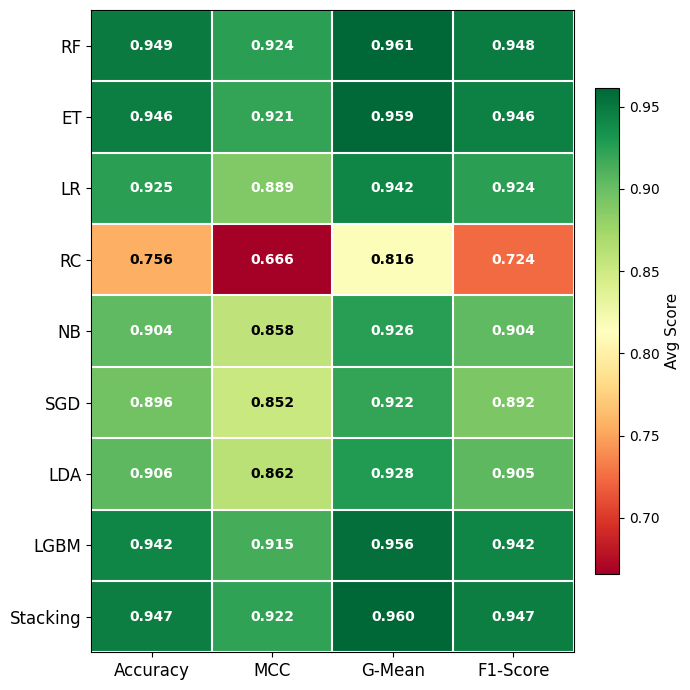

Saved: heatmap_avg_all_dfs.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ── DATA ──────────────────────────────────────────────────────────────────────

data = raw


# ── CONFIG ────────────────────────────────────────────────────────────────────

datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics  = ["Accuracy", "MCC", "G-Mean", "F1-Score"]   # ← AUROC বাদ

# ── STEP 1: প্রতিটা model-এর সব D-FS এর average ─────────────────────────────

avg_grid = np.full((len(models), len(metrics)), np.nan)

for i, model in enumerate(models):
    for k, metric in enumerate(metrics):
        vals = []
        for ds in datasets:
            v = data[ds][model][k] # Changed 'metric' to 'k' to access numeric index
            if v is not None:
                vals.append(v)
        if vals:
            avg_grid[i, k] = np.mean(vals)

# ── STEP 2: heatmap ───────────────────────────────────────────────────────────

cmap   = plt.cm.RdYlGn
vmin   = np.nanmin(avg_grid)
vmax   = np.nanmax(avg_grid)
masked = np.ma.masked_invalid(avg_grid)

fig, ax = plt.subplots(figsize=(7, 7))
im      = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

for i in range(len(models)):
    for k in range(len(metrics)):
        val      = avg_grid[i, k]
        if not np.isnan(val): # Added check for NaN values
            norm_val = (val - vmin) / (vmax - vmin)
            txt_col  = "white" if (norm_val < 0.25 or norm_val > 0.75) else "black"
            ax.text(k, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=10, color=txt_col, fontweight="bold")

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=12)

ax.set_xticks(np.arange(-0.5, len(metrics), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(models), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelsize=10)
cb.set_label("Avg Score", fontsize=11)

plt.tight_layout()
plt.savefig("heatmap_avg_all_dfs.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: heatmap_avg_all_dfs.png")

"AUROC is excluded as RC and SGD classifiers do not natively support probability estimation."